# Problem

In [52]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import random
import torch
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors

# This starts from the current working directory
# and goes up until it finds setup.py at the repository root
def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"
print(f"Project root found at: {PROJECT_ROOT}")
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

# Add project root to sys.path so we can import local packages
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
# Now define the dataset path
DATASET_PATH = DATASETS_DIR / "10grid_exp.csv"
DATASET_PATH1 = DATASETS_DIR / "20grid.csv"
print(f"Loading dataset from: {DATASET_PATH}")

from rl_methods import PolicySolver, EnvDataCollector
from rl_methods.fogas import (
    FOGASSolverVectorized,
    FOGASOracleSolverVectorized,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
)
from rl_methods.dataset_collection import DatasetAnalyzer
from rl_methods.fqi.fqi_solver import FQISolver
from rl_methods.fqi.fqi_evaluator import FQIEvaluator

seed = 44
np.random.seed(seed) # Add this
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root found at: /shared/home/mauro.diaz/work/FOGAS
Loading dataset from: /shared/home/mauro.diaz/work/FOGAS/datasets/10grid_exp.csv
Using device: cuda


# Problem

In [53]:
def plot_fogas_grid(grid_data):
    """
    Visualizes large grids (50x50, 100x100) for RL analysis.
    """
    size = grid_data.shape[0]
    
    # Mapping characters to numeric values for plotting
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    # Define a high-contrast color palette
    # Empty (White), Wall (Black), Pit (Red), Start (Blue), Goal (Green)
    colors = ['#FFFFFF', '#333333', '#FF0000', '#0000FF', '#00FF00']
    cmap = mcolors.ListedColormap(colors)
    
    # Set plot size to fit comfortably in a notebook
    plt.figure(figsize=(10, 10))
    plt.imshow(numeric_grid, cmap=cmap)
    
    # Grid lines to help distinguish cells in 50x50
    if size <= 50:
        plt.grid(which='both', color='grey', linestyle='-', linewidth=0.5, alpha=0.3)
        plt.xticks(np.arange(-0.5, size, 5), [])
        plt.yticks(np.arange(-0.5, size, 5), [])
    
    plt.title(f"FOGAS Environment: {size}x{size} Grid", fontsize=15)
    
    # Legend construction
    patches = [
        plt.plot([],[], marker="s", ms=10, ls="", color=colors[i], 
                 label=list(mapping.keys())[i])[0]  for i in range(len(colors))
    ]
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    plt.tight_layout()
    plt.show()

def scale_grid(small_grid, factor=2):
    """
    Takes a 50x50 grid and turns it into a 100x100 grid 
    by doubling every pixel (cell), making walls and pits twice as thick.
    """
    # Use numpy's repeat to double rows and columns
    large_grid = np.repeat(np.repeat(small_grid, factor, axis=0), factor, axis=1)
    
    # After scaling, we must ensure there is only ONE Start and ONE Goal
    # (Otherwise you'd have a 2x2 block of 'S' and 'G')
    large_grid[large_grid == 'S'] = '.'
    large_grid[large_grid == 'G'] = '.'
    
    large_grid[0, 0] = 'S'
    large_grid[-1, -1] = 'G'
    
    return large_grid

def plot_agent_paths(grid_data, paths, title_suffix=""):
    """
    Overlays agent trajectories on the FOGAS grid.
    'paths' should be a list of lists, e.g., [[(0,0), (0,1)...], [(0,0), (1,0)...]]
    """
    size = grid_data.shape[0]
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)
    
    colors = ['#FFFFFF', '#333333', '#FF0000', '#0000FF', '#00FF00']
    cmap = mcolors.ListedColormap(colors)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(numeric_grid, cmap=cmap)
    
    # Plot each path with a distinct style
    line_styles = ['-', '--', ':']
    path_colors = ['magenta', 'cyan', 'yellow']
    
    for i, path in enumerate(paths):
        if not path: continue
        rows, cols = zip(*path)
        plt.plot(cols, rows, label=f'Agent Path {i+1}', 
                 color=path_colors[i % 3], linestyle=line_styles[i % 3], 
                 linewidth=2, marker='o', markersize=3, alpha=0.8)

    plt.title(f"FOGAS Path Analysis: {size}x{size} {title_suffix}", fontsize=15)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    if size <= 50:
        plt.grid(which='both', color='grey', linestyle='-', linewidth=0.5, alpha=0.2)
        
    plt.tight_layout()
    plt.show()

def plot_agent_paths_with_labels(grid_data, paths, labels=None, title_suffix=""):
    """
    Overlays agent trajectories on the FOGAS grid with custom labels.
    """
    size = grid_data.shape[0]
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)
    
    colors = ['#FFFFFF', '#333333', '#FF0000', '#0000FF', '#00FF00']
    cmap = mcolors.ListedColormap(colors)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(numeric_grid, cmap=cmap)
    
    line_styles = ['-', '--', ':']
    path_colors = ['magenta', 'cyan', 'yellow']
    
    for i, path in enumerate(paths):
        if not path: continue
        label = labels[i] if labels and i < len(labels) else f'Path {i+1}'
        rows, cols = zip(*path)
        plt.plot(cols, rows, label=label, 
                 color=path_colors[i % 3], linestyle=line_styles[i % 3], 
                 linewidth=2, marker='o', markersize=3, alpha=0.8)

    plt.title(f"FOGAS Path Comparison: {size}x{size} {title_suffix}", fontsize=15)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    if size <= 50:
        plt.grid(which='both', color='grey', linestyle='-', linewidth=0.5, alpha=0.2)
        
    plt.tight_layout()
    plt.show()

def compute_optimal_path(mdp, mdp_data, size, max_steps=1000):
    """
    Computes the optimal path from start to goal by following mdp.pi_star 
    and looking up the resulting state in the transition matrix mdp.P.
    """
    current_state = mdp_data["start"]
    goal_state = mdp_data["goal"]
    pits = mdp_data["pits"]
    path = []
    
    for _ in range(max_steps):
        # Convert 1D state index back to 2D (row, col) coordinates
        r, c = divmod(current_state, size)
        path.append((r, c))
        
        # Stop condition: Reached the goal or fell into a pit
        if current_state == goal_state or current_state in pits:
            break
            
        # Extract the optimal action index from the pi_star vector at the current state
        best_a = torch.argmax(mdp.pi_star[current_state]).item()
        
        # Find the next state from the MDP transition matrix P
        # P has shape (N*A, N). The row index is: state * total_actions + action
        next_state = torch.argmax(mdp.P[current_state * mdp.A + best_a]).item()
        
        # Failsafe to prevent getting stuck in a loop against a wall
        if next_state == current_state:
            break
            
        current_state = next_state
        
    return path


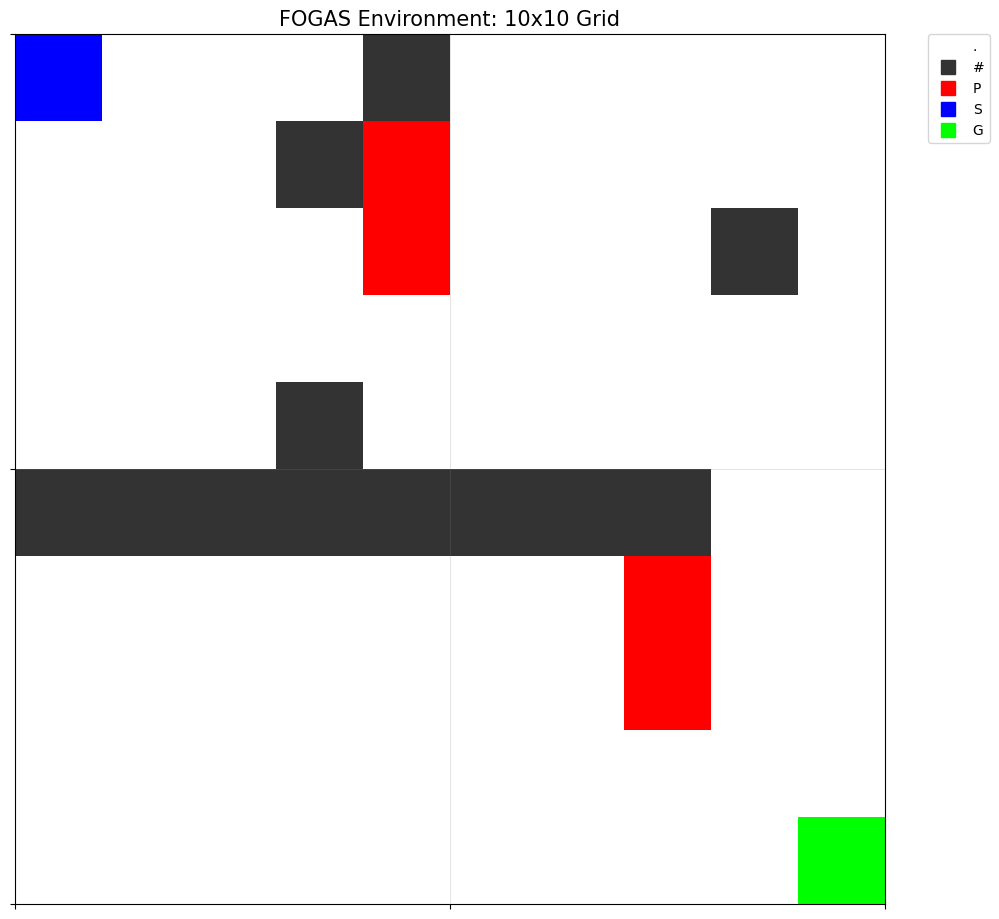

In [54]:
grid_layout = [
    "S...#.....",
    "...#P.....",
    "....P...#.",
    "..........",
    "...#......",
    "########..",
    ".......P..",
    ".......P..",
    "..........",
    ".........G"
]
# Load it as a 2D numpy array (how your environment expects it)
grid_10 = np.array([list(row) for row in grid_layout])
# To test it visually
plot_fogas_grid(grid_10)

# Linear MDP

In [55]:
def generate_mdp_regular_grid(grid_data, gamma=0.99):
    size = grid_data.shape[0]
    N = size * size
    A = 4
    
    walls = set(np.where(grid_data.flatten() == '#')[0])
    pits = set(np.where(grid_data.flatten() == 'P')[0])
    goal = np.where(grid_data.flatten() == 'G')[0][0]
    start_node = np.where(grid_data.flatten() == 'S')[0][0]

    # --- Regular Grid Center Generation ---
    # Target 50% of the total states (N)
    target_num_centers = int(N * 0.5)
    
    # Because we are making a square meshgrid, we need the "centers per side"
    # which is the square root of the target number of centers.
    centers_per_side = int(np.sqrt(target_num_centers))
    
    # Creates a meshgrid in normalized [0, 1] space
    ticks = np.linspace(0.0, 1.0, centers_per_side)
    c_x, c_y = np.meshgrid(ticks, ticks)
    centers = torch.tensor(np.column_stack([c_x.ravel(), c_y.ravel()]), dtype=torch.float64)
    
    def reward_fn(x, a):
        x_int = int(x)
        if x_int == goal: return 10.0
        if x_int in pits: return -10.0
        return -0.01

    P = torch.zeros((N * A, N), dtype=torch.float64)
    for x in range(N):
        for a in range(A):
            if x in pits or x == goal:
                P[x * A + a, x] = 1.0
                continue
            r, c = divmod(x, size)
            if a == 0: r_n, c_n = max(0, r-1), c
            elif a == 1: r_n, c_n = min(size-1, r+1), c
            elif a == 2: r_n, c_n = r, max(0, c-1)
            elif a == 3: r_n, c_n = r, min(size-1, c+1)
            next_s = r_n * size + c_n
            if next_s in walls: next_s = x
            P[x * A + a, next_s] = 1.0

    return {
        "centers": centers, "walls": walls, "pits": pits, 
        "goal": goal, "start": start_node, "reward_fn": reward_fn, 
        "P": P, "N": N, "A": A, "gamma": gamma
    }

def get_phi_state_func(centers, sigma, size, pits, goal):
    """Returns a scale-invariant phi_state function."""
    def phi_state(x):
        # Normalize coordinates based on the current grid size
        r, c = divmod(int(x), size)
        coords = torch.tensor([r / (size - 1), c / (size - 1)], dtype=torch.float64)
        
        # Calculate RBF activations
        dist_sq = torch.sum((coords - centers)**2, dim=1)
        rbf = torch.exp(-dist_sq / (2 * sigma**2))
        
        # Indicator features as per FOGAS standard practice
        is_pit = 1.0 if int(x) in pits else 0.0
        is_goal = 1.0 if int(x) == goal else 0.0
        indicators = torch.tensor([is_pit, is_goal], dtype=torch.float64)
        
        # Feature vector includes RBFs, Bias (1.0), and Indicators
        return torch.cat([rbf, torch.ones(1, dtype=torch.float64), indicators])
    return phi_state

def calculate_local_sigma(centers, k=2):
    """Computes sigma based on k-nearest neighbors for spatial precision."""
    dist_matrix = torch.cdist(centers, centers, p=2)
    topk_dists, _ = torch.topk(dist_matrix, k + 1, largest=False, dim=1)
    return torch.mean(topk_dists[:, 1])

def plot_grid_with_centers(grid_data, centers):
    size = grid_data.shape[0]
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)
    
    colors = ['#FFFFFF', '#333333', '#FF0000', '#0000FF', '#00FF00']
    cmap = mcolors.ListedColormap(colors)
    
    plt.figure(figsize=(12, 12))
    plt.imshow(numeric_grid, cmap=cmap)
    
    # Overlay Centers (Scaled back from [0,1] to [0, size-1])
    centers_scaled = centers.numpy() * (size - 1)
    plt.scatter(centers_scaled[:, 1], centers_scaled[:, 0], 
                c='blue', marker='x', s=size, label='RBF Feature Centers', alpha=0.6)
    
    plt.title(f"FOGAS Feature Allocation ({size}x{size})", fontsize=16)
    plt.legend(loc='upper right')
    plt.show()

## 10x10

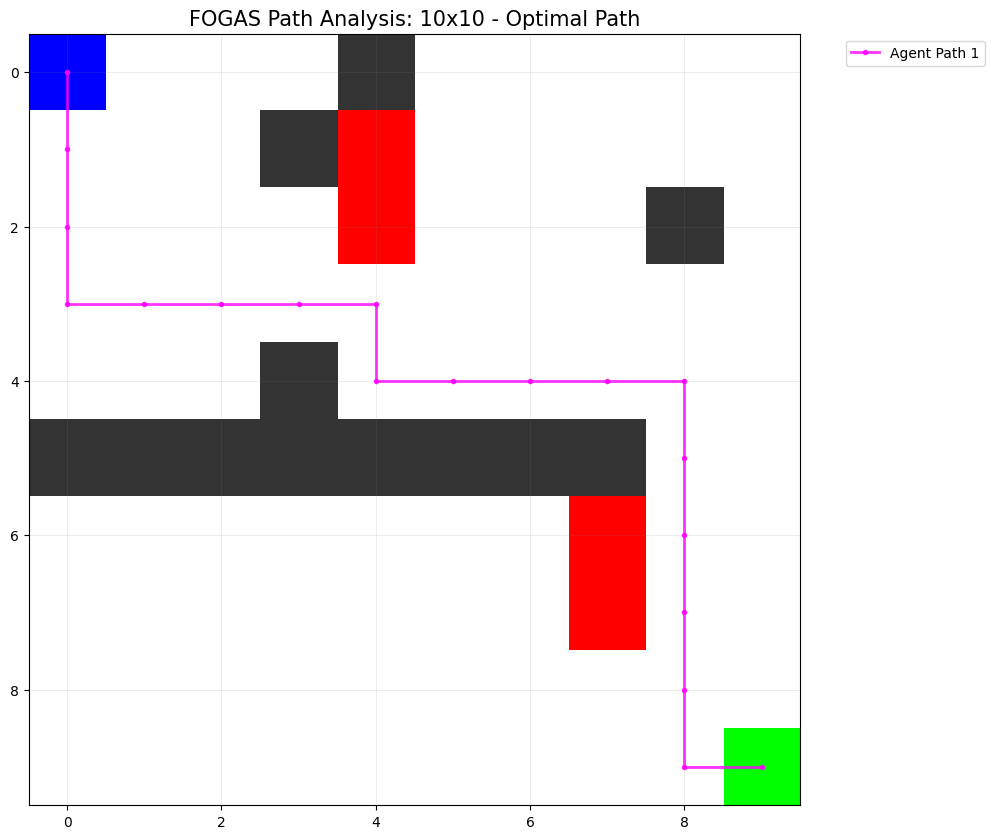

In [ ]:
grid_layout = [
    "S...#.....",
    "...#P.....",
    "....P...#.",
    "..........",
    "...#......",
    "########..",
    ".......P..",
    ".......P..",
    "..........",
    ".........G"
]
# Load it as a 2D numpy array (how your environment expects it)
grid_10 = np.array([list(row) for row in grid_layout])
size = 10

# --- STEP 2: Generate MDP Components with Regular Grid ---
# We use 15 centers per side (225 total RBFs) for a 50x50 or 100x100 grid.
mdp_data = generate_mdp_regular_grid(grid_10)

# --- STEP 3: Calculate Scale-Invariant Sigma ---
# Using Local KNN Sigma (k=2) ensures RBFs overlap with neighbors
# but don't become "blurry" across walls.
centers = mdp_data["centers"]
rbf_sigma = calculate_local_sigma(centers, k=2)

# --- STEP 4: Define the Scale-Invariant Phi Functions ---
# Note: size is passed here to ensure normalization: r / (size-1)
phi_s = get_phi_state_func(
    centers, 
    rbf_sigma, 
    size, 
    mdp_data["pits"], 
    mdp_data["goal"]
)

def phi(x, a):
    """Coupled Feature Map: phi(x, a) = e_a ⊗ phi_state(x)"""
    s_feat = phi_s(x)
    A = 4
    e_a = torch.zeros(A, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

# Calculate Feature Dimension d
sample_feat = phi(0, 0)
d = int(sample_feat.shape[0])

# --- STEP 5: Create the FOGAS Solver Object ---
# (Assumes your PolicySolver class is defined as in your previous code)
states = torch.arange(size * size, dtype=torch.int64)
actions = torch.arange(4, dtype=torch.int64)

mdp = PolicySolver(
    states=states, 
    actions=actions, 
    phi=phi,
    reward_fn=mdp_data["reward_fn"], 
    gamma=mdp_data["gamma"], 
    x0=mdp_data["start"], 
    P=mdp_data["P"]
)
optimal_path = compute_optimal_path(mdp, mdp_data, size=size)
# 2. Plot the trajectory
plot_agent_paths(grid_10, [optimal_path], title_suffix="- Optimal Path")

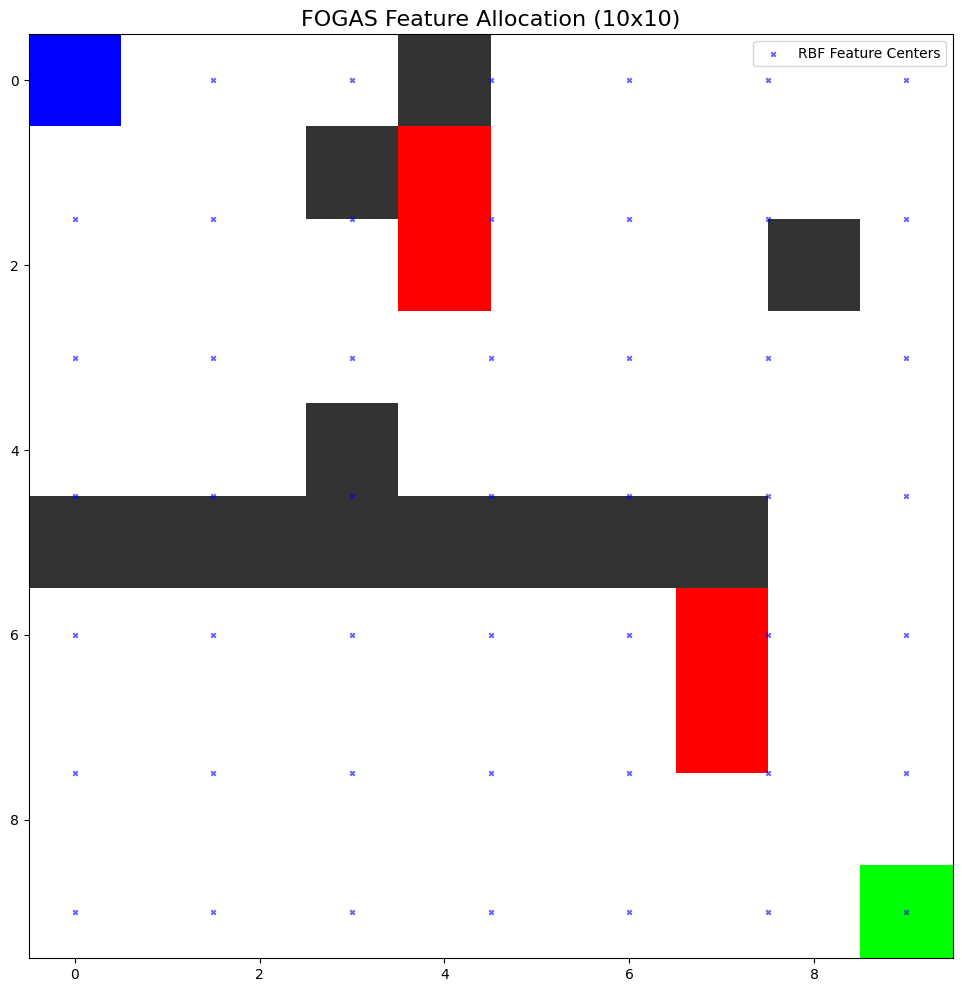

In [6]:
plot_grid_with_centers(grid_data=grid_10, centers=centers)

### Dataset creation

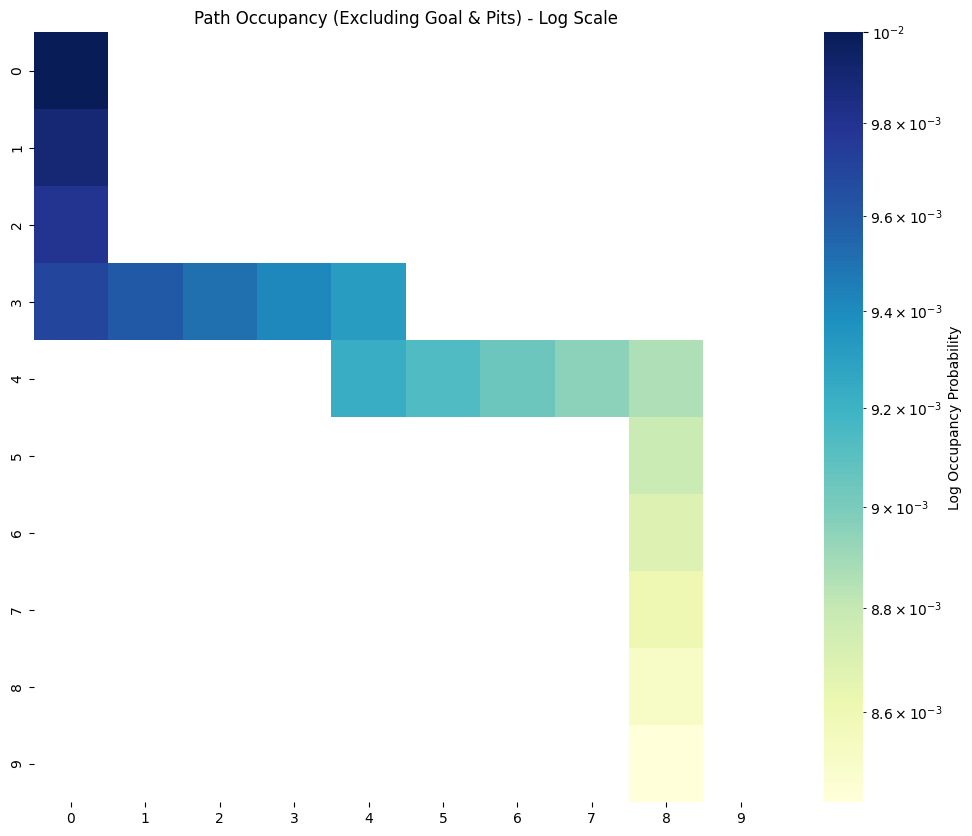

In [10]:
# 1. Get occupancy probabilities
probs = mdp.state_mu_star.detach().cpu().numpy().copy()

# 2. Mask the Goal/Pits (Terminal States) for better visual scaling
# The goal index is usually size*size - 1
terminal_indices = list(mdp_data['pits']) + [mdp_data['goal']]
for idx in terminal_indices:
    probs[idx] = 0.0

# 3. Reshape
grid_size = size
occupancy_grid = probs.reshape(grid_size, grid_size)

# 4. Plot with Log Normalization to see small probabilities along the path
plt.figure(figsize=(12, 10))
sns.heatmap(occupancy_grid, 
            cmap="YlGnBu", 
            norm=LogNorm(vmin=probs[probs>0].min() if any(probs>0) else 1e-6, vmax=probs.max()),
            cbar_kws={'label': 'Log Occupancy Probability'})

plt.title("Path Occupancy (Excluding Goal & Pits) - Log Scale")
plt.show()


In [14]:
reset_options = {
    'x0': 0.1, 
    'occupancy': 0.9
}

# Initialize the collector with these options
collector = EnvDataCollector(
    mdp=mdp,
    env_name="50grid",
    restricted_states=mdp_data["walls"],  # These will never be starting states
    reset_probs=reset_options,
    max_steps=200
)

# Create an epsilon-greedy pi_star (30% optimal, 70% random)
epsilon_policy = (mdp.pi_star, 0.3)

df = collector.collect_mixed_dataset_terminal_aware(
    policies=[epsilon_policy, "random"],  
    proportions=[0.8, 0.2],
    n_steps=10000,
    episode_based=True,                   
    save_path=str(DATASET_PATH),
    verbose=True,
    extra_steps=50 
)


  MIXED TERMINAL-AWARE DATASET COLLECTION SUMMARY (TORCH)
Total transitions: 10000
Total episodes: 135
Extra steps: 50

Policy Distribution:
  Policy 0:  7189 steps (71.9%) | Target: 80.0% | Episodes: 112
  Policy 1:  2811 steps (28.1%) | Target: 20.0% | Episodes: 24

✅ Mixed terminal-aware dataset saved to: /shared/home/mauro.diaz/work/FOGAS/datasets/10grid_exp.csv


In [17]:
analyzer = DatasetAnalyzer(DATASET_PATH)

ratio = analyzer.feature_coverage_ratio(
    mdp=mdp,
    beta=1e-6,
    use_optimal_policy=True,
    verbose=True,
    return_details=True,
)


Feature Coverage Ratio Details
------------------------------
  Dataset size (n):         10000
  MDP dims (N, A, d):        (100, 4, 208)
  gamma:                    0.99
  beta (ridge):             1e-06
  policy source:            provided

  Occupancy μ_pi summary:
    sum:                    1
    min / max:              0 / 0.834514

  Feature occupancy λ_pi summary:
    ||λ||_2:                1.66147
    ||λ||_1:                5.27676
    max |λ_i|:              0.834514

  Empirical covariance Λ_n:
    diag min / mean / max:  1.04882e-06 / 0.0198363 / 0.518401
    eig min / max:          1e-06 / 1.51132
    condition number:       1.51132e+06

  Coverage ratio:           2.19567


Total states: 100
Walls: 12
Visited: 60
Non-visited non-walls: 28


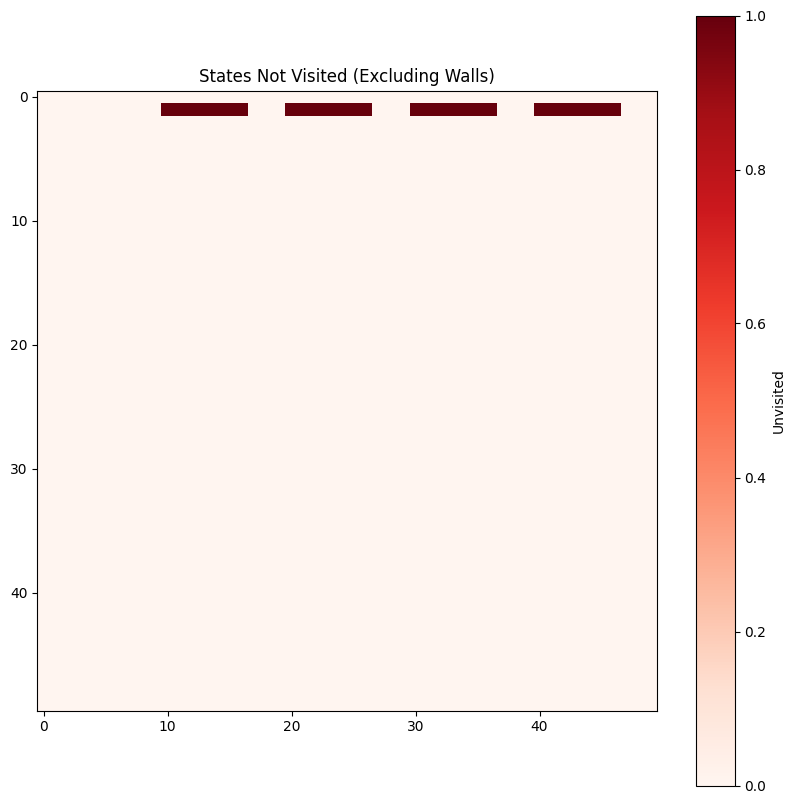

In [18]:
# 1. Get all visited states from your collected dataset
visited_states = set(df['state'].unique())

# 2. Get the set of wall states
# Since you are in the 50x50grid notebook, mdp_data contains the wall indices
wall_states = set(mdp_data['walls'])

# 3. Calculate states that were NOT visited and are NOT walls
all_states = set(range(mdp.N))
non_visited_non_walls = all_states - visited_states - wall_states

print(f"Total states: {mdp.N}")
print(f"Walls: {len(wall_states)}")
print(f"Visited: {len(visited_states)}")
print(f"Non-visited non-walls: {len(non_visited_non_walls)}")

# Optional: Convert indices to (row, col) coordinates for the 50x50 grid
size = 50
coords = [divmod(s, size) for s in sorted(list(non_visited_non_walls))]
# print(coords[:10]) # Show first 10 missing states

# Create an empty 50x50 map (0 = visited/wall, 1 = missing)
coverage_map = np.zeros((size, size))
for s in non_visited_non_walls:
    r, c = divmod(s, size)
    coverage_map[r, c] = 1
plt.figure(figsize=(10, 10))
plt.imshow(coverage_map, cmap='Reds')
plt.title("States Not Visited (Excluding Walls)")
plt.colorbar(label="Unvisited")
plt.show()


### Solving it

[FOGASSolverVectorized] omega estimated via regression (beta_omega=1.00e-07, n=10000)

     REWARD APPROXIMATION ANALYSIS
Metric                                Value
────────────────────────────────────────────
Max |error|                        0.062983
Mean |error|                       0.004149
RMSE                               0.009642
R² (explained variance)            0.999982


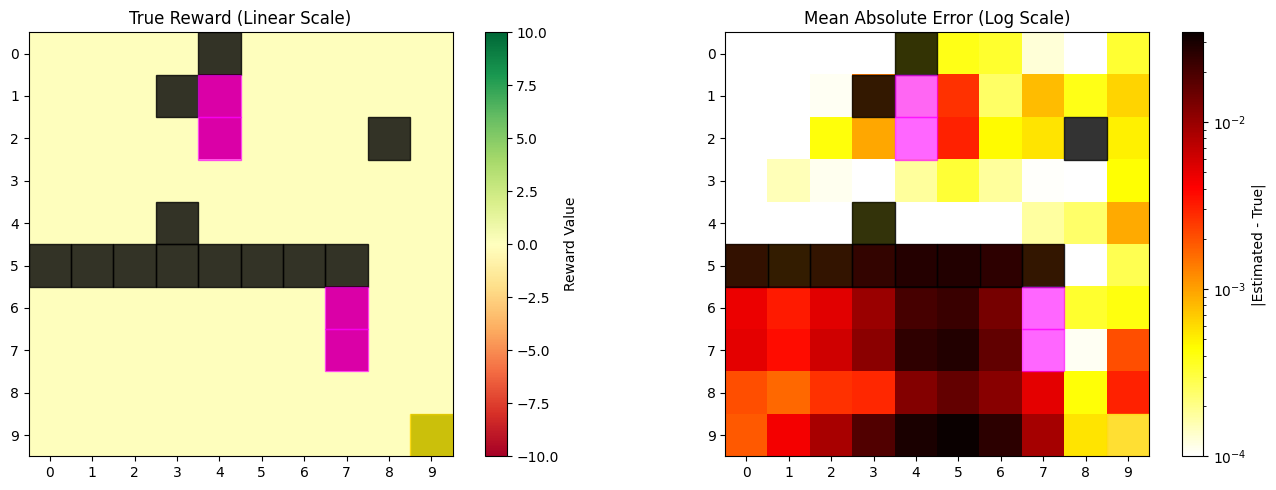

In [24]:
solver_e = FOGASSolverVectorized(
    mdp=mdp,
    csv_path=str(DATASET_PATH),
    device=device,
    beta=1e-7,
    seed=seed)
evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(solver=solver_e,metric_callable=evaluator_e.get_metric("reward"), seed=seed)

evaluator_e.analyze_reward_approximation(
    walls=mdp_data["walls"], 
    pits=mdp_data["pits"], 
    goal=mdp_data["goal"]
    )

In [29]:
# Run solver with best alpha and fixed rho, eta
solver_e.run(alpha=0.0001 / 2, eta=0.00002, rho=0.5, tqdm_print=True, T=10000)
evaluator_e.print_optimal_path(goal_state=mdp_data["goal"])

FOGAS: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:05<00:00, 1809.97it/s]


  OPTIMAL PATH VISUALIZATION - Learned Policy (π_FOGAS)

Initial State: 0
Goal State: 99
Discount Factor (γ): 0.99

----------------------------------------------------------------------

  Step   0 │ State: 0        │ Action: 1       │ Reward:  -0.010 │ → 10
  Step   1 │ State: 10       │ Action: 1       │ Reward:  -0.010 │ → 20
  Step   2 │ State: 20       │ Action: 1       │ Reward:  -0.010 │ → 30
  Step   3 │ State: 30       │ Action: 3       │ Reward:  -0.010 │ → 31
  Step   4 │ State: 31       │ Action: 3       │ Reward:  -0.010 │ → 32
  Step   5 │ State: 32       │ Action: 3       │ Reward:  -0.010 │ → 33
  Step   6 │ State: 33       │ Action: 3       │ Reward:  -0.010 │ → 34
  Step   7 │ State: 34       │ Action: 1       │ Reward:  -0.010 │ → 44
  Step   8 │ State: 44       │ Action: 3       │ Reward:  -0.010 │ → 45
  Step   9 │ State: 45       │ Action: 3       │ Reward:  -0.010 │ → 46
  Step  10 │ State: 46       │ Action: 3       │ Reward:  -0.010 │ → 47
  Step  11 │ State:

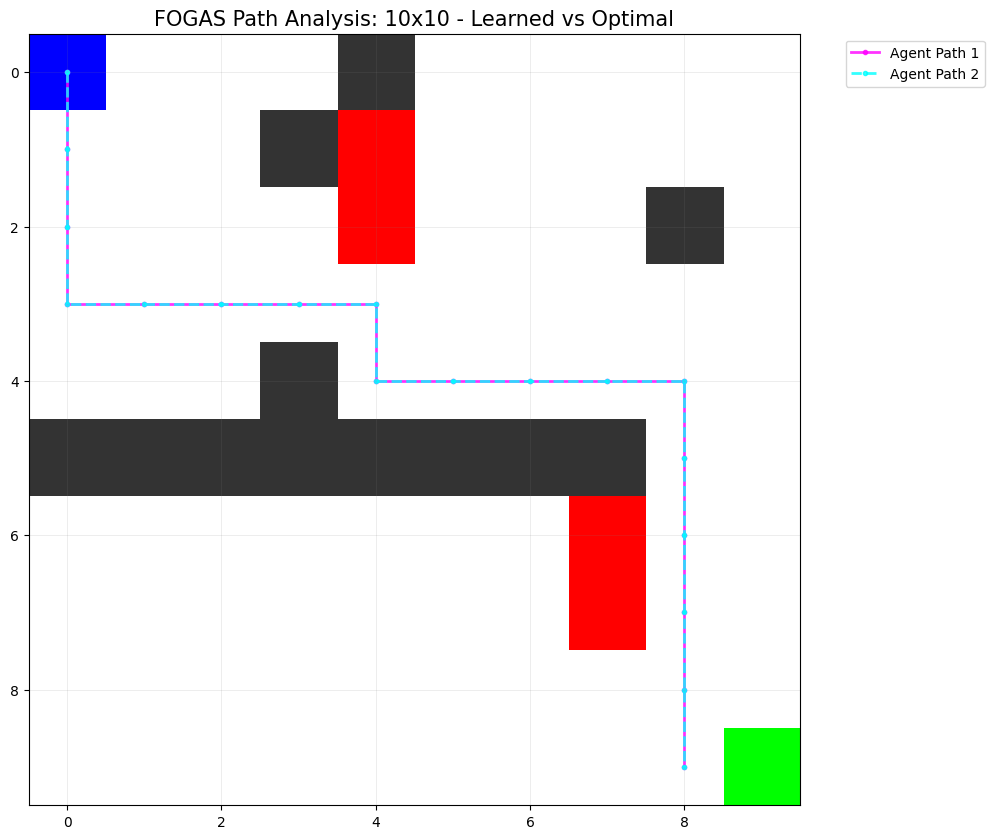

In [32]:
traj = evaluator_e.simulate_trajectory(goal_state=mdp_data["goal"])
# 2. Extract the state indices and convert them to (row, col) coordinates
size = grid_10.shape[0]
path_coords = [divmod(step['state'], size) for step in traj]
# Simulate the optimal policy trajectory
traj_opt = evaluator_e.simulate_trajectory(pi=evaluator_e.mdp.pi_star, goal_state=mdp_data["goal"])
path_opt = [divmod(step['state'], size) for step in traj_opt]

# Plot both to see how close your learned policy is to optimal
plot_agent_paths(grid_10, [path_coords, path_opt], title_suffix="- Learned vs Optimal")

In [33]:
evaluator_e.print_optimal_path(goal_state=mdp_data["goal"])


  OPTIMAL PATH VISUALIZATION - Learned Policy (π_FOGAS)

Initial State: 0
Goal State: 99
Discount Factor (γ): 0.99

----------------------------------------------------------------------

  Step   0 │ State: 0        │ Action: 1       │ Reward:  -0.010 │ → 10
  Step   1 │ State: 10       │ Action: 1       │ Reward:  -0.010 │ → 20
  Step   2 │ State: 20       │ Action: 1       │ Reward:  -0.010 │ → 30
  Step   3 │ State: 30       │ Action: 3       │ Reward:  -0.010 │ → 31
  Step   4 │ State: 31       │ Action: 3       │ Reward:  -0.010 │ → 32
  Step   5 │ State: 32       │ Action: 3       │ Reward:  -0.010 │ → 33
  Step   6 │ State: 33       │ Action: 3       │ Reward:  -0.010 │ → 34
  Step   7 │ State: 34       │ Action: 1       │ Reward:  -0.010 │ → 44
  Step   8 │ State: 44       │ Action: 3       │ Reward:  -0.010 │ → 45
  Step   9 │ State: 45       │ Action: 3       │ Reward:  -0.010 │ → 46
  Step  10 │ State: 46       │ Action: 3       │ Reward:  -0.010 │ → 47
  Step  11 │ State:

## 20x20

In [56]:
# 1. Define base grid and scale it
grid_10 = np.array([list(row) for row in grid_layout])
grid_20 = scale_grid(grid_10, factor=2)
size_10, size_20 = grid_10.shape[0], grid_20.shape[0]

# 2. Generate MDP components freshly
mdp_data_10 = generate_mdp_regular_grid(grid_10)
mdp_data_20 = generate_mdp_regular_grid(grid_20)

# 3. Extract the ground-truth feature space
fixed_centers = mdp_data_10["centers"]
fixed_sigma = calculate_local_sigma(fixed_centers, k=2)

# 4. Explicitly redefine the 10x10 feature map to avoid stale closures
phi_s_10 = get_phi_state_func(fixed_centers, fixed_sigma, size_10, mdp_data_10["pits"], mdp_data_10["goal"])

def phi_10_fixed(x, a):
    s_feat = phi_s_10(x)
    e_a = torch.zeros(4, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

# 5. Define the 20x20 feature map using the exact same centers
phi_s_20 = get_phi_state_func(fixed_centers, fixed_sigma, size_20, mdp_data_20["pits"], mdp_data_20["goal"])

def phi_20_fixed(x, a):
    s_feat = phi_s_20(x)
    e_a = torch.zeros(4, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)
# --- STEP 7: Create the FOGAS Solver Object for 20x20 ---
# Ensure we are using the correct state and action spaces for the 20x20 grid
states_20 = torch.arange(size_20 * size_20, dtype=torch.int64)
actions_20 = torch.arange(4, dtype=torch.int64)

# Initialize the solver
mdp_20 = PolicySolver(
    states=states_20, 
    actions=actions_20, 
    phi=phi_20_fixed,          # The rigorously aligned feature map
    reward_fn=mdp_data_20["reward_fn"], 
    gamma=mdp_data_20["gamma"], 
    x0=mdp_data_20["start"], 
    P=mdp_data_20["P"]
)

We build the second optimal policy:

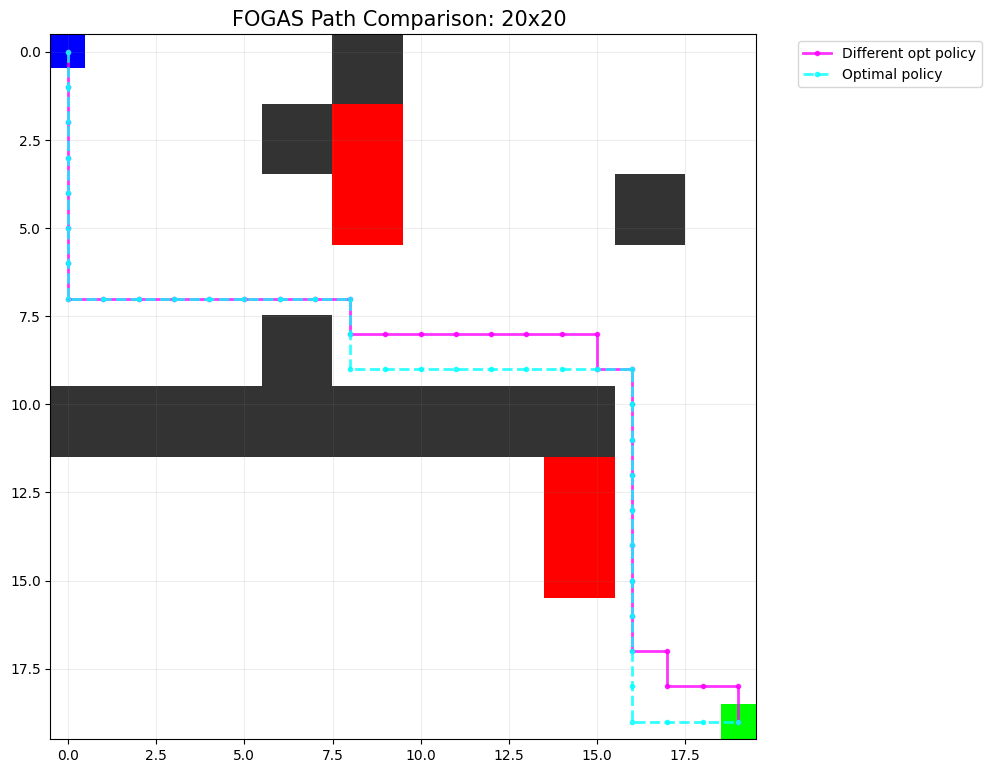

In [57]:
opt_path_waypoints = [
    (0,0), (7,0),   # Go down to row 7
    (7,8),          # Go right to col 8
    (8,8), (8,15),  # Step into row 8 and go right (avoiding the wall at row 10)
    (9,15), (9,16), # Reposition to col 16
    (17,16),        # Go down to row 17
    (17,17), (18,17), # Step right and down
    (18,19),        # Go right to col 19
    (19,19)         # Final step to goal
]

def build_waypoint_policy(mdp, waypoints, grid_size=20):
    """Creates a policy matrix that follows a sequence of (r, c) coordinates."""
    N, A = mdp.N, mdp.A
    pi = np.ones((N, A)) / A  # Start with uniform random everywhere
    
    # helper to get action index (0=Up, 1=Down, 2=Left, 3=Right)
    for i in range(len(waypoints)-1):
        r1, c1 = waypoints[i]
        r2, c2 = waypoints[i+1]
        
        # Fill all states between waypoints with the required direction
        dr, dc = np.sign(r2 - r1), np.sign(c2 - c1)
        curr_r, curr_c = r1, c1
        
        while (curr_r, curr_c) != (r2, c2):
            s = int(curr_r * grid_size + curr_c)
            action = -1
            if dr != 0 and curr_r != r2:
                action = 1 if dr > 0 else 0 # Down or Up
                curr_r += dr
            elif dc != 0 and curr_c != c2:
                action = 3 if dc > 0 else 2 # Right or Left
                curr_c += dc
            
            if action != -1:
                pi[s] = 0.0
                pi[s, action] = 1.0
                
    return torch.tensor(pi, dtype=torch.float64)

    
pi_opt_manual = build_waypoint_policy(mdp_20, pink_path_waypoints)
pi_fogas = mdp_20.pi_star.clone()
mdp_20.pi_star = pi_opt_manual
manual_path_20 = compute_optimal_path(mdp_20, mdp_data_20, size=size_20)
mdp_20.pi_star = pi_fogas
optimal_path_20 = compute_optimal_path(mdp_20, mdp_data_20, size=size_20)


# Usage:
labels = ["Different opt policy", "Optimal policy"]
plot_agent_paths_with_labels(grid_20, [manual_path_20, optimal_path_20], labels)

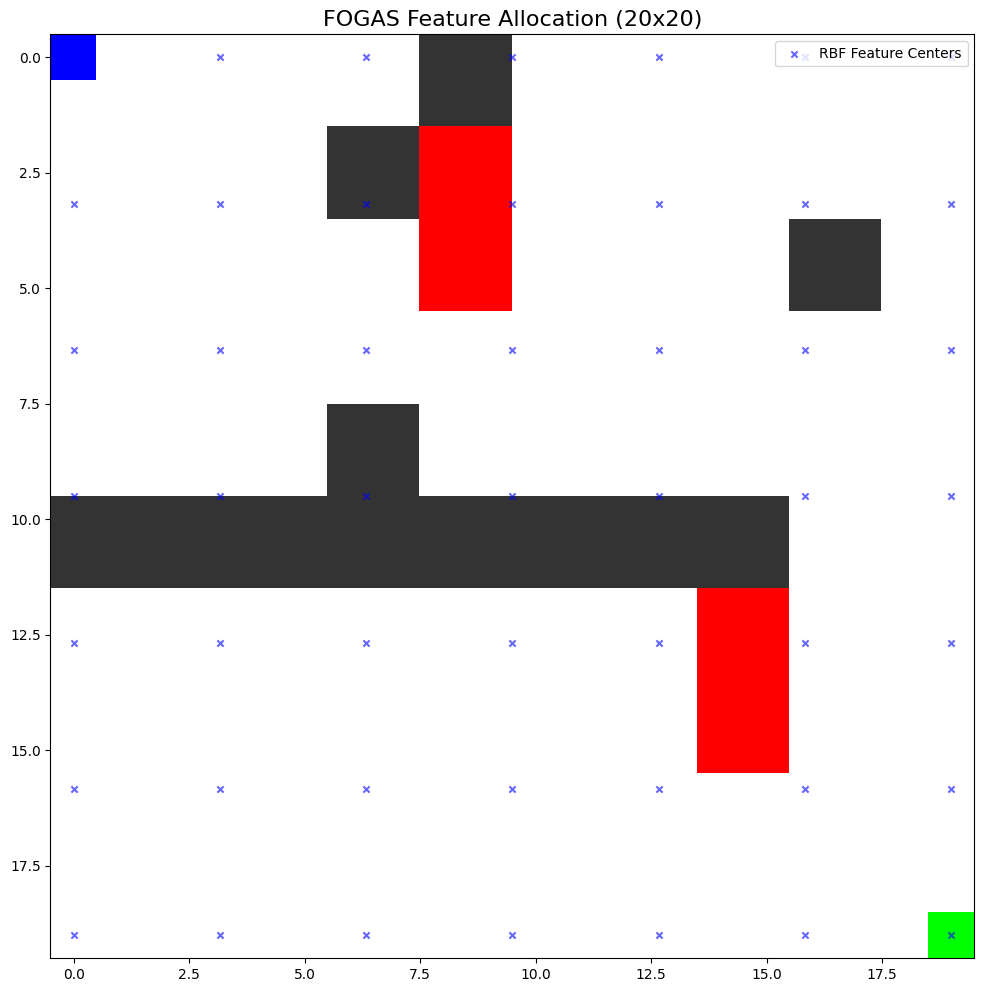

In [58]:
plot_grid_with_centers(grid_data=grid_20, centers=fixed_centers)

### Dataset collection

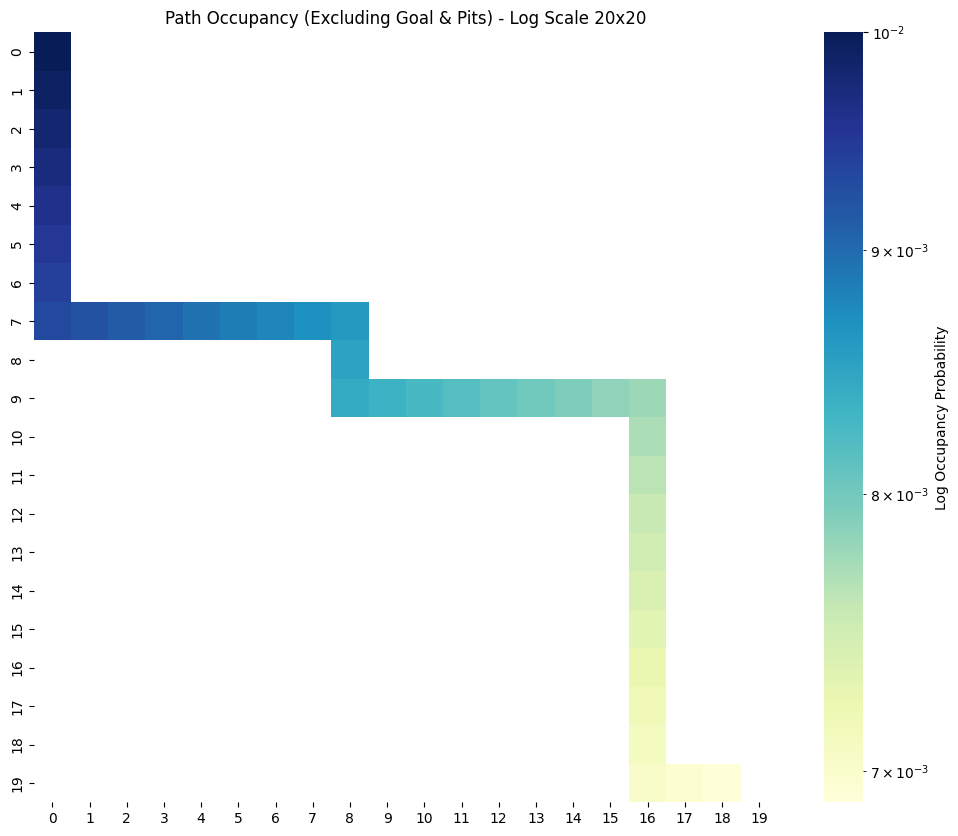

In [59]:
# 1. Get occupancy probabilities for the 100x100 MDP
probs20 = mdp_20.state_mu_star.detach().cpu().numpy().copy()

# 2. Mask the Goal/Pits (Terminal States) for better visual scaling
# Uses the mdp1_data containing indices for the 100x100 grid
terminal_indices1 = list(mdp_data_20['pits']) + [mdp_data_20['goal']]
for idx in terminal_indices1:
    probs20[idx] = 0.0

# 3. Reshape using the new grid size
grid_size1 = 20
occupancy_grid1 = probs20.reshape(grid_size1, grid_size1)

# 4. Plot with Log Normalization
plt.figure(figsize=(12, 10))
sns.heatmap(
    occupancy_grid1, 
    cmap="YlGnBu", 
    norm=LogNorm(
        vmin=probs20[probs20 > 0].min() if any(probs20 > 0) else 1e-6, 
        vmax=probs20.max()
    ),
    cbar_kws={'label': 'Log Occupancy Probability'}
)

plt.title(f"Path Occupancy (Excluding Goal & Pits) - Log Scale {grid_size1}x{grid_size1}")
plt.show()


Data collection with both polcies:

In [71]:
reset_options1 = {
    'x0': 0.0, 
    'occupancy': 1.0 
}

# Initialize the collector for the 20x20 grid
collector1 = EnvDataCollector(
    mdp=mdp_20,
    env_name="20grid",                   
    restricted_states=mdp_data_20["walls"], 
    reset_probs=reset_options1,
    max_steps=100                         
)

# Behavior policy: 80% epsilon-greedy, 20% random
epsilon_policy1 = (mdp_20.pi_star, 0.3)
epsilon_policy_opt = (pi_opt_manual, 0.3)

# 3. Use it in your data collector
df1 = collector1.collect_mixed_dataset_terminal_aware(
    policies=[epsilon_policy1, epsilon_policy_opt, "random"],  
    proportions=[0.5, 0.3, 0.2],  # 40% Optimal, 40% Pink Path, 20% Random
    n_steps=16000, 
    episode_based=True,                   
    save_path=str(DATASET_PATH1),
    verbose=True
)


  MIXED TERMINAL-AWARE DATASET COLLECTION SUMMARY (TORCH)
Total transitions: 16000
Total episodes: 369
Extra steps: 5

Policy Distribution:
  Policy 0:  6358 steps (39.7%) | Target: 50.0% | Episodes: 194
  Policy 1:  5611 steps (35.1%) | Target: 30.0% | Episodes: 113
  Policy 2:  4031 steps (25.2%) | Target: 20.0% | Episodes: 63

✅ Mixed terminal-aware dataset saved to: /shared/home/mauro.diaz/work/FOGAS/datasets/20grid.csv


In [61]:
# Initialize the analyzer with your dataset path
analyzer = DatasetAnalyzer(str(DATASET_PATH1))

# Define the states you want to check
states_to_check = [379, 359, 398]

# Get the counts
state_counts = analyzer.count_states(states_to_check)

# Print the results
print("State Frequencies in Dataset:")
for state, count in state_counts.items():
    print(f"  State {state}: {count} times")

State Frequencies in Dataset:
  State 379: 191 times
  State 359: 83 times
  State 398: 519 times


Total states (100x100): 400
Walls: 48
Visited: 307
Non-visited non-walls: 45


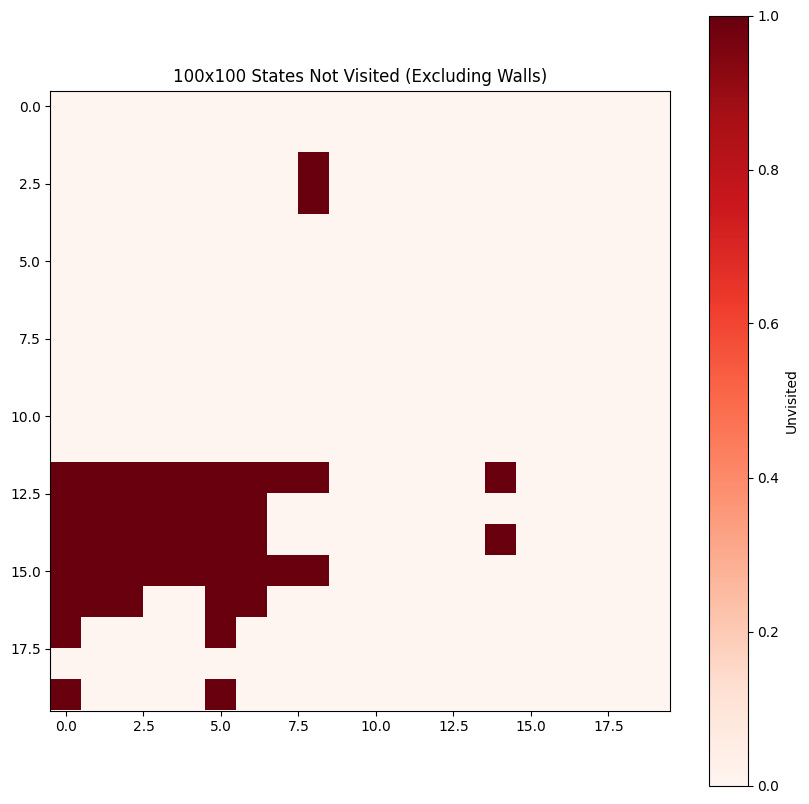

In [62]:
# 1. Get all visited states from your collected 100x100 dataset
visited_states1 = set(df1['state'].unique())

# 2. Get the set of wall states for the 100x100 grid
wall_states1 = set(mdp_data_20['walls'])

# 3. Calculate states that were NOT visited and are NOT walls
all_states1 = set(range(mdp_20.N))
non_visited_non_walls1 = all_states1 - visited_states1 - wall_states1

print(f"Total states (100x100): {mdp_20.N}")
print(f"Walls: {len(wall_states1)}")
print(f"Visited: {len(visited_states1)}")
print(f"Non-visited non-walls: {len(non_visited_non_walls1)}")

# Convert indices to (row, col) coordinates for the 100x100 grid
size1 = 20
coords1 = [divmod(s, size1) for s in sorted(list(non_visited_non_walls1))]

# Create an empty 100x100 map (0 = visited/wall, 1 = missing)
coverage_map1 = np.zeros((size1, size1))
for s in non_visited_non_walls1:
    r, c = divmod(s, size1)
    coverage_map1[r, c] = 1

plt.figure(figsize=(10, 10))
plt.imshow(coverage_map1, cmap='Reds')
plt.title(f"100x100 States Not Visited (Excluding Walls)")
plt.colorbar(label="Unvisited")
plt.show()

### Solving it

[FOGASSolverVectorized] omega estimated via regression (beta_omega=1.00e-07, n=16000)

     REWARD APPROXIMATION ANALYSIS
Metric                                Value
────────────────────────────────────────────
Max |error|                        0.005170
Mean |error|                       0.000506
RMSE                               0.001189
R² (explained variance)            1.000000


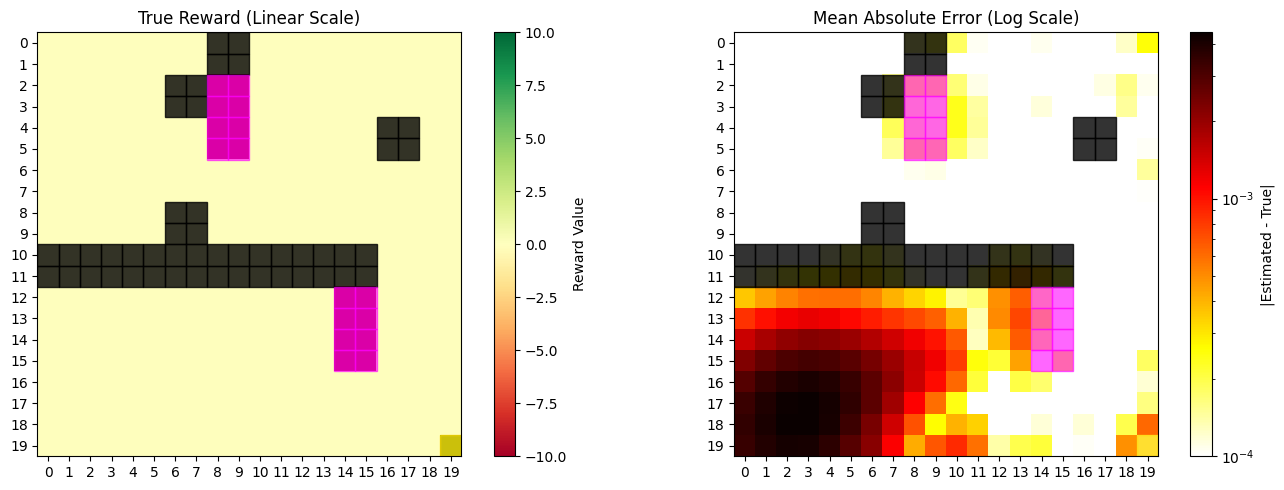

In [72]:
# Initialize the vectorized solver for the 100x100 dataset
solver1_e = FOGASSolverVectorized(
    mdp=mdp_20,
    csv_path=str(DATASET_PATH1),
    device=device,
    beta=1e-7,
    seed=seed
)

# Initialize the evaluator for the 100x100 solver
evaluator1_e = FOGASEvaluator(solver1_e)

# Initialize the hyperparameter optimizer for 100x100
optimizer1_e = FOGASHyperOptimizer(
    solver=solver1_e,
    metric_callable=evaluator1_e.get_metric("reward"), 
    seed=seed
)

# Run the reward approximation analysis on the 100x100 environment
evaluator1_e.analyze_reward_approximation(
    walls=mdp_data_20["walls"], 
    pits=mdp_data_20["pits"], 
    goal=mdp_data_20["goal"]
)


In [ ]:
solver1_e.run(
    alpha=0.0001,
    eta=0.00002, 
    rho=0.5, 
    tqdm_print=True, 
    T=25000
)

evaluator1_e.print_optimal_path(goal_state=mdp_data_20["goal"])

NameError: name 'solver1_e' is not defined

In [77]:
evaluator1_e.print_policy()

  State 0: π(a=0|s=0) = 0.20  π(a=1|s=0) = 0.38  π(a=2|s=0) = 0.20  π(a=3|s=0) = 0.22  --> best action: 1
  State 1: π(a=0|s=1) = 0.16  π(a=1|s=1) = 0.34  π(a=2|s=1) = 0.04  π(a=3|s=1) = 0.46  --> best action: 3
  State 2: π(a=0|s=2) = 0.12  π(a=1|s=2) = 0.22  π(a=2|s=2) = 0.01  π(a=3|s=2) = 0.65  --> best action: 3
  State 3: π(a=0|s=3) = 0.13  π(a=1|s=3) = 0.16  π(a=2|s=3) = 0.00  π(a=3|s=3) = 0.71  --> best action: 3
  State 4: π(a=0|s=4) = 0.19  π(a=1|s=4) = 0.16  π(a=2|s=4) = 0.00  π(a=3|s=4) = 0.65  --> best action: 3
  State 5: π(a=0|s=5) = 0.31  π(a=1|s=5) = 0.18  π(a=2|s=5) = 0.01  π(a=3|s=5) = 0.50  --> best action: 3
  State 6: π(a=0|s=6) = 0.41  π(a=1|s=6) = 0.18  π(a=2|s=6) = 0.04  π(a=3|s=6) = 0.37  --> best action: 0
  State 7: π(a=0|s=7) = 0.39  π(a=1|s=7) = 0.16  π(a=2|s=7) = 0.12  π(a=3|s=7) = 0.33  --> best action: 0
  State 8: π(a=0|s=8) = 0.28  π(a=1|s=8) = 0.13  π(a=2|s=8) = 0.21  π(a=3|s=8) = 0.38  --> best action: 3
  State 9: π(a=0|s=9) = 0.18  π(a=1|s=9) = 0.1

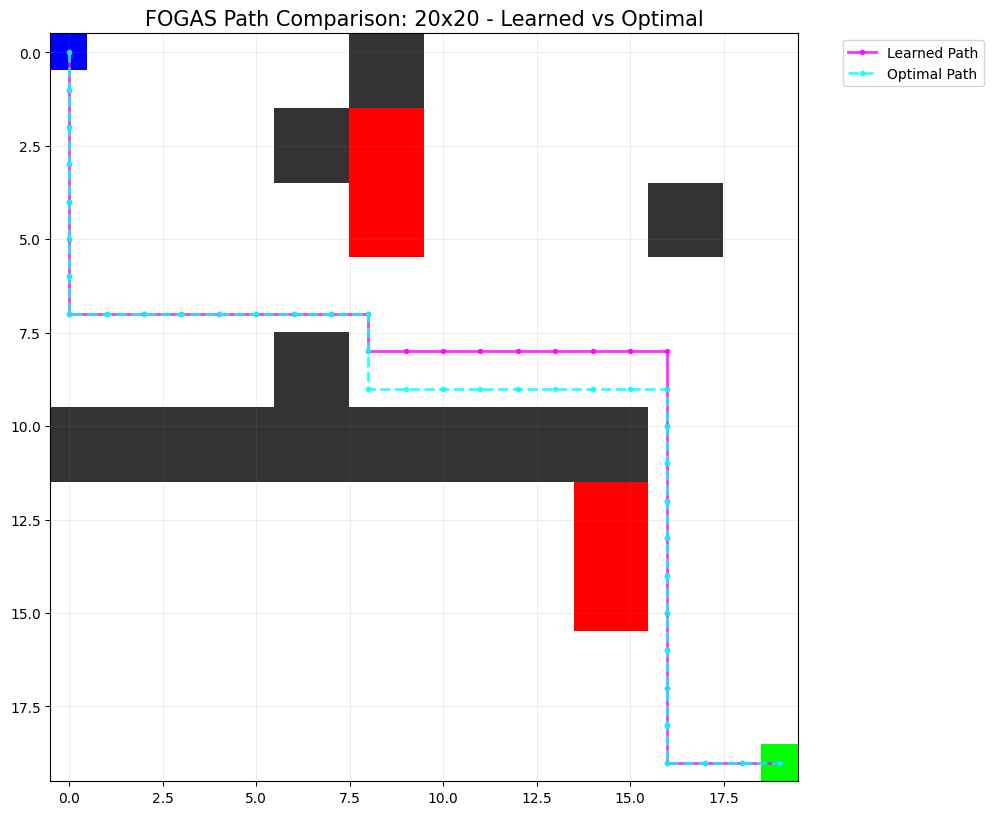

In [78]:
# 1. Simulate the trajectories
traj = evaluator1_e.simulate_trajectory(goal_state=mdp_data_20["goal"])
traj_opt = evaluator1_e.simulate_trajectory(pi=evaluator1_e.mdp.pi_star, goal_state=mdp_data_20["goal"])

size = grid_20.shape[0]

# 2. Extract path coordinates and include the final 'next_state' (the goal)
path_coords = [divmod(step['state'], size) for step in traj]
if traj:
    path_coords.append(divmod(traj[-1]['next_state'], size))

path_opt = [divmod(step['state'], size) for step in traj_opt]
if traj_opt:
    path_opt.append(divmod(traj_opt[-1]['next_state'], size))

plot_agent_paths_with_labels(
    grid_20, 
    paths=[path_coords, path_opt], 
    labels=["Learned Path", "Optimal Path"], 
    title_suffix="- Learned vs Optimal"
)